<a href="https://colab.research.google.com/github/IanPerigoUERN/NexVisual/blob/main/NexVisual_Desafio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desafio 1**

## Neste desafio, você irá implementar uma solução simples para aplicar o efeito de desfoque no fundo de uma imagem contendo uma pessoa, de forma semelhante ao recurso utilizado em aplicativos de videochamadas

In [1]:

import cv2


from google.colab import drive

import os

import numpy as np

import matplotlib.pyplot as plt



from google.colab.patches import cv2_imshow




Fonte da foto :

https://www.rte.ie/sport/soccer/2026/0603/1576651-abankwah-irelands-loi-contingent-shows-league-growth/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


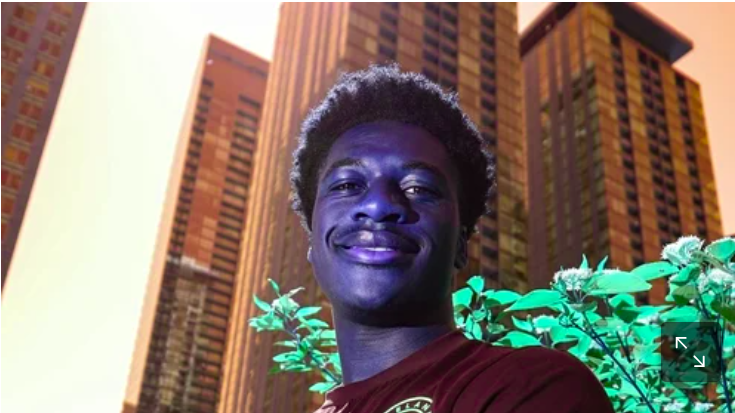

In [2]:
drive.mount('/content/drive')


directory = '/content/drive/MyDrive/nexvisual_files/'


os.makedirs(directory, exist_ok=True)


image = cv2.imread (directory + 'frontal-face.png')

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

cv2_imshow(image)


Rostos encontrados: 1


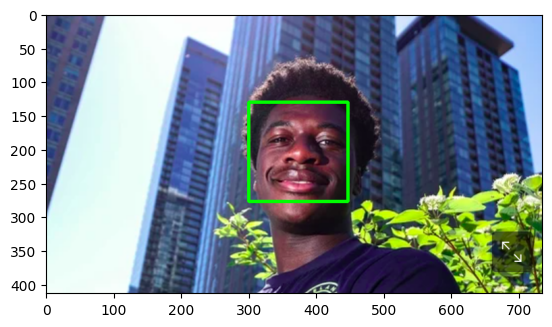

In [3]:




face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.3, # se não achar o rosto, baixar para 1.05
    minNeighbors=3,  # se não achar o rosto, baixar para 3 ou 4

)

print(f"Rostos encontrados: {len(faces)}")


copy_image_rgb = image.copy()
padding = 100

# # 4. Processa apenas se encontrou algum rosto
# if len(faces) > 0:
#     # Desenha o retângulo em todos os rostos
#     for (x,y,w,h) in faces:
#         cv2.rectangle(image, (x,y), (x+w,y+h), (0,255,0), 2)

for (x, y, larg, alt) in faces: #Desenhar o retângulo
    ret = cv2.rectangle(copy_image_rgb, (x, y), (x + larg, y + alt), (0, 255, 0), 3)
    y, height = max(0, y-padding), min(y+alt+padding, image.shape[0])
    x, width = max(0, x-padding), min(x+larg+padding, image.shape[1])
    face_img = image[y:height,x:width,:]
plt.imshow(copy_image_rgb)

In [4]:
# Imagem borrada
blurred_image = cv2.GaussianBlur(image, (31, 31), 20)

In [5]:
# Máscara inicialmente zerada
mask = np.zeros(copy_image_rgb.shape[:2], dtype=np.uint8)

for (x, y, w, h) in faces:

    # Ajuste fino do tamanho da área nítida
    padding = 80

    center = (x + w // 2, y + h // 2)

    axes = (
        (w + padding) // 2,
        (h + padding) // 2
    )

    # Desenha uma elipse branca na máscara
    cv2.ellipse(
        mask,
        center,
        axes,
        0,
        0,
        360,
        255,
        -1
    )

# Suaviza as bordas da máscara
mask = cv2.GaussianBlur(mask, (101, 101), 0)

# Converte para 3 canais e normaliza
mask = mask.astype(np.float32) / 255.0
mask = cv2.merge([mask, mask, mask])

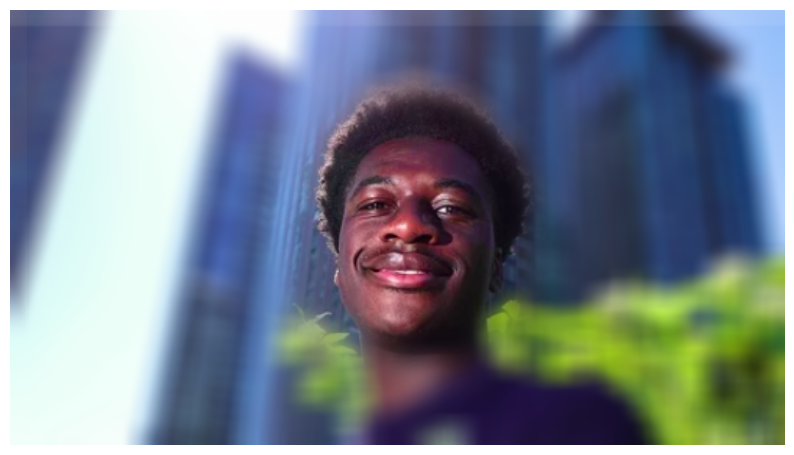

In [6]:
# Mistura as imagens
final_image = (
    image.astype(np.float32) * mask +
    blurred_image.astype(np.float32) * (1 - mask)
)

final_image = final_image.astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(final_image)
plt.axis("off")
plt.show()